


Examining and Visualizing Data
=============================


<div class="alert alert-block alert-info"> 
<h2>Overview</h2>

<strong>Questions:</strong>

* How can I use pandas to process data?

* How can I visualize relationships between different parts of my data?

<strong>Objectives:</strong>

* Use pandas and seaborn to load and explore data

</div>

## The Pandas data science library

[Pandas](https://pandas.pydata.org/docs/) is a Python library used for data analysis and manipulation. Within the world of data science, it is a ubiquitous and widely used library. If you are learning how to analyze data in Python, it will be almost impossible to avoid pandas. 

As with any python library, we need to import pandas to use its functions.  A common practice is to abbreviate `pandas` as `pd`. 

In [1]:
import pandas as pd

The central data structure of pandas is called a DataFrame. Pandas DataFrames work very closely with NumPy arrays and Pandas dataframes are specifically for data which is two dimensional (rows and columns). NumPy arrays, while similar in some ways, can work with higher dimensional data.  Very broadly, NumPy arrays are designed to work with data that is all one data type, whereas Pandas dataframes are designed to work with a variety of data types.

Pandas is very powerful. In this session, we'll be learning how to access information in pandas dataframes and how to do some basic manipulation and analysis. We are going to be looking at a dataset which gives information about the elements in the periodic table.

In [3]:
# Creating a pandas dataframe by reading in a CSV file.
df = pd.read_csv("../data/PubChemElements_all.csv")

## Examining Data

Initially when loading data in, and also at certain points as we're working with it, we'll want to see what our dataframe looks like. You can see a preview of your dataframe using the `.head` function

When you preview the dataframe, you will see that the rows are labeled with numbers and the columns are labeled with column names.

In [4]:
# The default behavior is to show the first five rows of a dataframe
# You can change this by putting a different number in the parenthesis
df.head()

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808


The `.info` function will give information about the columns and the data type of those columns. The data type will become very important later as we work with data more.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   AtomicNumber           118 non-null    int64  
 1   Symbol                 118 non-null    object 
 2   Name                   118 non-null    object 
 3   AtomicMass             118 non-null    float64
 4   CPKHexColor            108 non-null    object 
 5   ElectronConfiguration  118 non-null    object 
 6   Electronegativity      95 non-null     float64
 7   AtomicRadius           113 non-null    float64
 8   IonizationEnergy       102 non-null    float64
 9   ElectronAffinity       57 non-null     float64
 10  OxidationStates        103 non-null    object 
 11  StandardState          118 non-null    object 
 12  MeltingPoint           103 non-null    float64
 13  BoilingPoint           93 non-null     float64
 14  Density                96 non-null     float64
 15  GroupB

For this dataframe, we see that the first column, `AtomicNumber` has the data type of `int64`. Here, `int` means `integer` and `64` means `64 bit`.  The `64 bit` refers to the amount of computer memory the variable can occupy. It won't really be important for us. Similarly, `float64` means `64 bit floating point`. These are decimal numbers.

The other column names which read `object` are not numeric. They might be strings or they might be something else. 

The `describe` function can be used on a dataframe to quickly see statistics about columns with numerical data. If you look at the columns that statistics are computed for and compare to the data type shown from `info`, you will see that we only get statistics for columns which had `int64` or `float64` data types.

In [6]:
df.describe()

,AtomicNumber,AtomicMass,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,MeltingPoint,BoilingPoint,Density
count,118.000000,118.000000,95.000000,113.000000,102.000000,57.000000,103.000000,93.000000,96.000000
mean,59.500000,146.607635,1.732316,201.902655,7.997255,1.072140,1273.740553,2536.212473,7.608001
std,34.207699,89.845304,0.635187,42.025707,3.339066,0.879163,888.853859,1588.410919,5.878692
min,1.000000,1.008000,0.700000,120.000000,3.894000,0.079000,0.950000,4.220000,0.000090
25%,30.250000,66.480000,1.290000,180.000000,6.020500,0.470000,516.040000,1180.000000,2.572500
50%,59.500000,142.573850,1.620000,202.000000,6.960000,0.754000,1191.000000,2792.000000,7.072000
75%,88.750000,226.777165,2.170000,229.000000,8.998500,1.350000,1806.500000,3618.000000,10.275250
max,118.000000,294.214000,3.980000,348.000000,24.587000,3.617000,3823.000000,5869.000000,22.570000


This information is extremely useful for understanding the data. We can also easily visualize the distribution of each column using Pandas's ``hist`` function.

array([[<Axes: title={'center': 'AtomicNumber'}>,
        <Axes: title={'center': 'AtomicMass'}>,
        <Axes: title={'center': 'Electronegativity'}>],
       [<Axes: title={'center': 'AtomicRadius'}>,
        <Axes: title={'center': 'IonizationEnergy'}>,
        <Axes: title={'center': 'ElectronAffinity'}>],
       [<Axes: title={'center': 'MeltingPoint'}>,
        <Axes: title={'center': 'BoilingPoint'}>,
        <Axes: title={'center': 'Density'}>]], dtype=object)

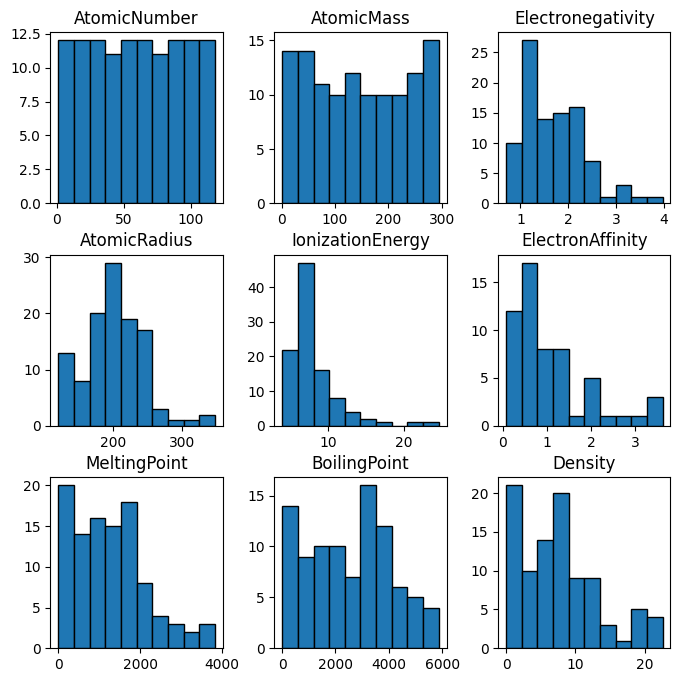

In [7]:
df.hist(figsize=(8,8), edgecolor='black', grid=False)

## Accessing Data

Pandas dataframes have names for rows (called the "index" in Pandas) and columns.

Pandas dataframes have rows and columns, you can see how many rows and columns using `.shape`. This will return the shape as `(num_rows, num_columns)`.

In [8]:
df.shape

(118, 17)

There are a few methods for accessing information in a Pandas dataframe, but the one that will be most important in this workshop is selecting particular columns of data.

In [9]:
# Look at the atomic number column
# It won't show the whole column because it's too long
df["AtomicNumber"]

0        1
1        2
2        3
3        4
4        5
      ... 
113    114
114    115
115    116
116    117
117    118
Name: AtomicNumber, Length: 118, dtype: int64

In [10]:
# You could also show two columns at once
# You can combine with the .head() function to just show the beginning
df[["Symbol", "ElectronConfiguration"]].head() 

,Symbol,ElectronConfiguration
0,H,1s1
1,He,1s2
2,Li,[He]2s1
3,Be,[He]2s2
4,B,[He]2s2 2p1


## Performing calculations with pandas: No more `for` loops!

Both pandas and NumPy dataframes have the convenient feature that they can do element-wise operations and use something called `broadcasting`. This means that if you are doing something like subtracting a number, multiplying, etc to a column or dataframe of information, it can be done all at once instead of with a `for` loop.  We saw this previously in our NumPy lesson.  

Consider if we wanted to calculate the melting point in degrees celsius for all of the elements. Instead of writing a `for` loop that does this, we can just write the following code. 

In [11]:
df['MeltingPoint'] - 273.15

0      -259.34
1      -272.20
2       180.50
3      1286.85
4      2074.85
        ...   
113        NaN
114        NaN
115        NaN
116        NaN
117        NaN
Name: MeltingPoint, Length: 118, dtype: float64

We could do this one two columns as well.  In that case, we would have a list of column names instead of just one column name.  This is why there are the double brackets in this notation; the inner brackets are specifying the list of column names. 

In [12]:
df[['MeltingPoint', 'BoilingPoint']] - 273.15

,MeltingPoint,BoilingPoint
0,-259.34,-252.87
1,-272.20,-268.93
2,180.50,1341.85
3,1286.85,2470.85
4,2074.85,3999.85
...,...,...
113,NaN,NaN
114,NaN,NaN
115,NaN,NaN
116,NaN,NaN


We can save these in new dataframe columns

In [13]:
df[["MeltingPointC", "BoilingPointC"]] = df[['MeltingPoint', 'BoilingPoint']] - 273.15

#Show the dataframe again to check our our new columns
df.head()

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered,MeltingPointC,BoilingPointC
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766,-259.34,-252.87
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868,-272.20,-268.93
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817,180.50,1341.85
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798,1286.85,2470.85
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808,2074.85,3999.85


### The `.apply` method

The `.apply` method in pandas is used to apply a function along a row or column of a dataframe.
This is useful when you have a custom function that you need to use on every value in a column, but there is not a NumPy or Pandas function for it.

For example, we could apply the `len` function to our `Name` column to get the number of letters in the name for each element.

In [14]:
# Number of letters in name - 
df["Name"].apply(len)

0       8
1       6
2       7
3       9
4       5
       ..
113     9
114     9
115    11
116    10
117     9
Name: Name, Length: 118, dtype: int64

<div class="alert alert-block alert-success"> 
<strong>The .apply function</strong>

Notice that when we use `.apply`, we write the <strong>name</strong> of the function we want to apply, 
but we do not <strong>call</strong> the function. 
If we were to call the `len` function, we would use parentheses `()` with an argument.

</div>

## Using RDKit Functions with Pandas DataFrames
Using `len` to calculate the number of letters in an atom name is a silly example, but for an example more related to our work with RDKit, let's add some additional atomic data.

RDKit has the ability to get information about atoms.
We can create a periodic table with `Chem.GetPeriodicTable`, then use associated functions to get information about atoms.

In [15]:
from rdkit import Chem

In [16]:
# Initialize the periodic table
periodic_table = Chem.GetPeriodicTable()

After we have a periodic table, we can apply functions from the periodic table to the atoms in our dataframe.

In [17]:
df["NOuter"] = df["Symbol"].apply(periodic_table.GetNOuterElecs)
df.head()

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered,MeltingPointC,BoilingPointC,NOuter
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766,-259.34,-252.87,1
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868,-272.20,-268.93,2
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817,180.50,1341.85,1
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798,1286.85,2470.85,2
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808,2074.85,3999.85,3


<div class="alert alert-block alert-warning">
<h3>Exercise</h3>

Use the `tab` key on your periodic table object to check for other values you can calculate for atoms.
Pick one to add to your periodic table dataset.

</div>

In [18]:
# Your code goes here

In [19]:
# Code for default valence
# There are lots of options
df["DefaultValence"] = df["Symbol"].apply(periodic_table.GetDefaultValence)
df.head()

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,...,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered,MeltingPointC,BoilingPointC,NOuter,DefaultValence
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,...,Gas,13.81,20.28,0.000090,Nonmetal,1766,-259.34,-252.87,1,1
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,...,Gas,0.95,4.22,0.000179,Noble gas,1868,-272.20,-268.93,2,0
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,...,Solid,453.65,1615.00,0.534000,Alkali metal,1817,180.50,1341.85,1,1
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,...,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798,1286.85,2470.85,2,2
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,...,Solid,2348.00,4273.00,2.370000,Metalloid,1808,2074.85,3999.85,3,3


We can save a CSV file with our newly calculated values using the `to_csv` function.

In [21]:
df.to_csv("../data/periodic_data_processed.csv")

## Visualization

Visualizing data helps in understanding relationships and patterns that might not be apparent from raw data. Here, we will use Seaborn, a statistical visualization library, to create plots from our periodic table dataset. Seaborn is built on top of matplotlib, so if we would like to adjust any of the plots seaborn makes, we can do that through the Matplotlib interface we've used before.

We will start with a bar plot to show the ionization energy of elements across different group blocks:


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

/Users/armcdona/anaconda3/lib/python3.11/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12'),
  Text(12, 0, '13'),
  Text(13, 0, '14'),
  Text(14, 0, '15')])

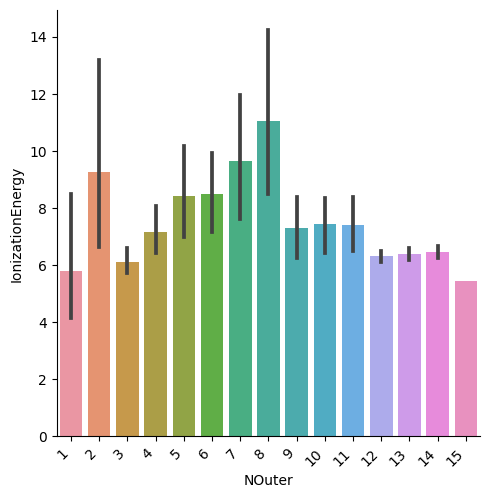

In [23]:
sns.catplot(data=df, x="NOuter", y="IonizationEnergy", kind="bar")
# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

The plot above shows us periodic trends that we learned about in introductory chemistry. The two highest ionization energy categories correspond to elements with 2 valence electrons and 8 valence electrons, representing filled shells.

Seaborn can also allow us to easily create scatter plots to visualize relationships between continuous variables. For example, we can create a scatter plot to show the relationship between ionization energy and atomic radius:

Text(0, 0.5, 'Electronegativity')

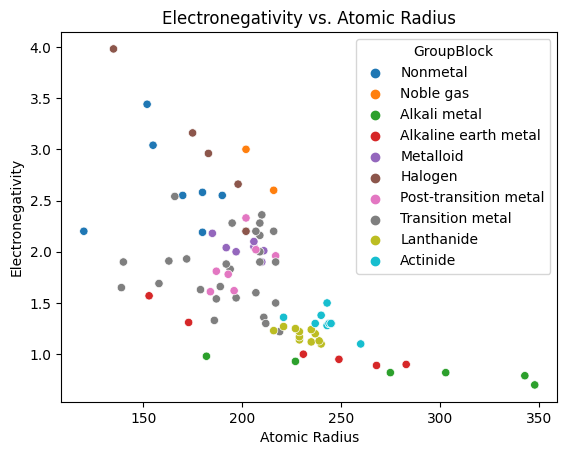

In [24]:
sns.scatterplot(data=df, x="AtomicRadius", y="Electronegativity", hue="GroupBlock")
plt.title('Electronegativity vs. Atomic Radius')
plt.xlabel('Atomic Radius')
plt.ylabel('Electronegativity')

<div class="alert alert-block alert-warning">
<h3>Exercise</h3>

Create a few other categorical plots to observe periodic trends.  Note, these instructions are given as y vs. x.

1. Electronegativity vs. Group Block as a bar plot.

2. Melting Point vs. Group Block as a bar plot.

3. Ionization Energy vs. Atomic Number as a scatter plot colored by GroupBlock.
   
</div>

In [25]:
# Your code goes here.  Add additional cells if needed.

/Users/armcdona/anaconda3/lib/python3.11/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Nonmetal'),
  Text(1, 0, 'Noble gas'),
  Text(2, 0, 'Alkali metal'),
  Text(3, 0, 'Alkaline earth metal'),
  Text(4, 0, 'Metalloid'),
  Text(5, 0, 'Halogen'),
  Text(6, 0, 'Post-transition metal'),
  Text(7, 0, 'Transition metal'),
  Text(8, 0, 'Lanthanide'),
  Text(9, 0, 'Actinide')])

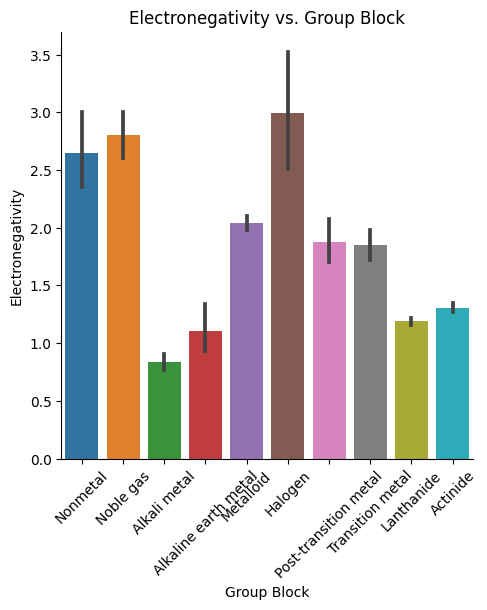

In [26]:
sns.catplot(data=df, x="GroupBlock", y="Electronegativity", kind="bar")
plt.title('Electronegativity vs. Group Block')
plt.xlabel('Group Block')
plt.ylabel('Electronegativity')
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Nonmetal'),
  Text(1, 0, 'Noble gas'),
  Text(2, 0, 'Alkali metal'),
  Text(3, 0, 'Alkaline earth metal'),
  Text(4, 0, 'Metalloid'),
  Text(5, 0, 'Halogen'),
  Text(6, 0, 'Post-transition metal'),
  Text(7, 0, 'Transition metal'),
  Text(8, 0, 'Lanthanide'),
  Text(9, 0, 'Actinide')])

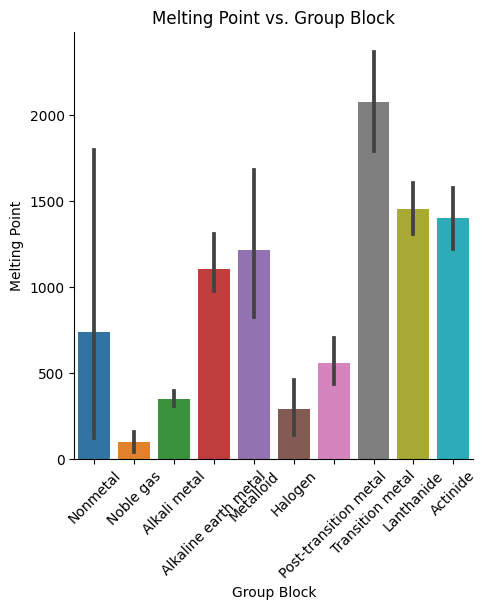

In [27]:
sns.catplot(data=df, x="GroupBlock", y="MeltingPoint", kind="bar")
plt.title('Melting Point vs. Group Block')
plt.xlabel('Group Block')
plt.ylabel('Melting Point')
plt.xticks(rotation=45)

Text(0, 0.5, 'Ionization Energy')

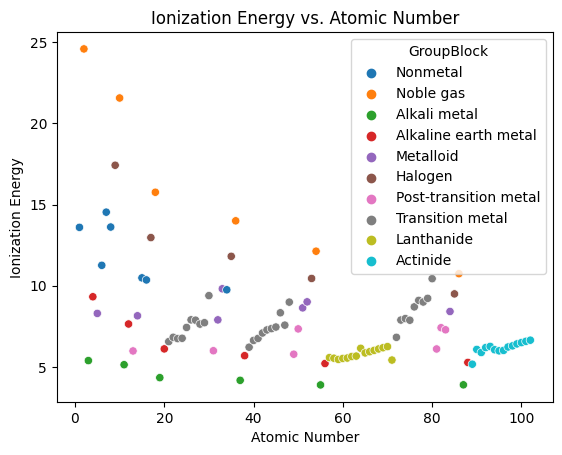

In [28]:
sns.scatterplot(data=df, x="AtomicNumber", y="IonizationEnergy", hue="GroupBlock")
plt.title('Ionization Energy vs. Atomic Number')
plt.xlabel('Atomic Number')
plt.ylabel('Ionization Energy')

### Visualizing Correlation

A common way to visualize relationships between different categories of data categories is with a correlation plot.
The correlation matrix provides insights into the relationships between the variables. A correlation value close to 1 indicates a strong positive relationship, while a correlation value close to -1 indicates a strong negative relationship. A correlation value close to 0 indicates no relationship between the features.

In [29]:
# Calculate the correlation matrix
corr = df.corr(numeric_only=True)
corr

,AtomicNumber,AtomicMass,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,MeltingPoint,BoilingPoint,Density,MeltingPointC,BoilingPointC,NOuter,DefaultValence
AtomicNumber,1.000000,0.999258,-0.333108,0.108260,-0.436061,0.033849,0.186428,0.368187,0.725570,0.186428,0.368187,0.070370,-0.506853
AtomicMass,0.999258,1.000000,-0.332860,0.103125,-0.421957,0.035010,0.176436,0.358071,0.720749,0.176436,0.358071,0.063630,-0.498457
Electronegativity,-0.333108,-0.332860,1.000000,-0.658565,0.904801,0.712926,-0.118976,-0.288225,-0.085101,-0.118976,-0.288225,0.184604,0.280172
AtomicRadius,0.108260,0.103125,-0.658565,1.000000,-0.641088,-0.317003,0.057317,0.213469,0.187537,0.057317,0.213469,0.091258,0.012166
IonizationEnergy,-0.436061,-0.421957,0.904801,-0.641088,1.000000,0.695265,-0.327232,-0.499358,-0.332260,-0.327232,-0.499358,0.048754,0.196028
ElectronAffinity,0.033849,0.035010,0.712926,-0.317003,0.695265,1.000000,-0.294207,-0.423421,-0.068024,-0.294207,-0.423421,0.447026,0.164286
MeltingPoint,0.186428,0.176436,-0.118976,0.057317,-0.327232,-0.294207,1.000000,0.888202,0.571981,1.000000,0.888202,0.242993,-0.381001
BoilingPoint,0.368187,0.358071,-0.288225,0.213469,-0.499358,-0.423421,0.888202,1.000000,0.684276,0.888202,1.000000,0.143610,-0.413294
Density,0.725570,0.720749,-0.085101,0.187537,-0.332260,-0.068024,0.571981,0.684276,1.000000,0.571981,0.684276,0.330893,-0.522202
MeltingPointC,0.186428,0.176436,-0.118976,0.057317,-0.327232,-0.294207,1.000000,0.888202,0.571981,1.000000,0.888202,0.242993,-0.381001


Seaborn can be used to create a heatmap to allow easier examination of the correlation of different variables.

<Axes: >

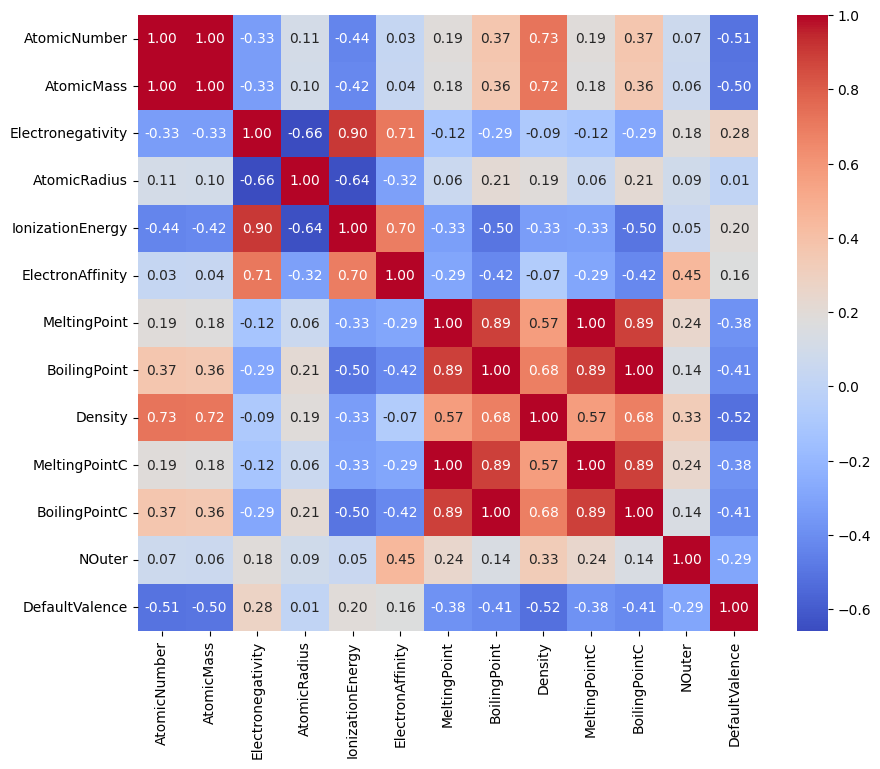

In [30]:
# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

The heatmap uses a "coolwarm" color scheme where red indicates positive correlation and blue indicates negative correlation between variables. Strongly correlated pairs are represented by darker shades of red, while strongly inversely correlated pairs are represented by darker shades of blue.

<div class="alert alert-block alert-warning">
<h3>Final Activity</h3>

For our final activity, we will redo the activity we did last week in lab where we created a dataset for the amino acids using RDKit.  This time, instead of writing the data to a file, you will be creating a pandas dataset. You should be able to use Pandas and the `.apply` function to add new columns of data to your DataFrame. 

The creation of a starting dataframe is done for you in the code cell below.  Add additional code to add the following columns to your dataframe:
1. The molecule object created from each SMILES string
2. Molecular Weight
3. Number of Heavy Atoms
4. One or two more molecular descriptors of your choosing

Compare and contrast the code - which one do you prefer? 


</div>

In [32]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools

# Ensure molecules are rendered in the notebook
PandasTools.RenderImagesInAllDataFrames(images=True)

filehandle = open("../data/amino_acids.txt", "r")
amino_acid_data = filehandle.readlines()
filehandle.close()

# Delete the new line character at the end of each smiles string
smiles_list = []
for smiles in amino_acid_data:
    smiles = smiles.strip()
    smiles_list.append(smiles)

# Initialize the dataframe with the list
df = pd.DataFrame(smiles_list, columns=["SMILES"])


,SMILES,Molecule,MolWt,NumHeavy,TPSA
0,C[C@H](N)C(=O)O,,89.094,6,63.32
1,NC(N)=NCCC[C@H](N)C(=O)O,,174.204,12,127.72
2,NC(=O)C[C@H](N)C(=O)O,,132.119,9,106.41

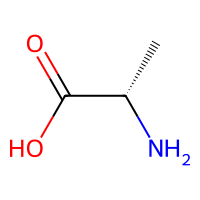
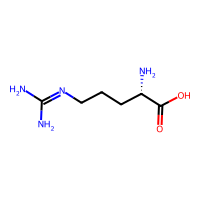
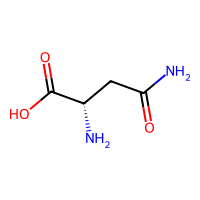

In [34]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools

# Ensure molecules are rendered in the notebook
PandasTools.RenderImagesInAllDataFrames(images=True)

filehandle = open("../data/amino_acids.txt", "r")
amino_acid_data = filehandle.readlines()
filehandle.close()

# Delete the new line character at the end of each smiles string
smiles_list = []
for smiles in amino_acid_data:
    smiles = smiles.strip()
    smiles_list.append(smiles)

# Initialize the dataframe with the list
df = pd.DataFrame(smiles_list, columns=["SMILES"])

# Make the molecule column first
df["Molecule"] = df["SMILES"].apply(Chem.MolFromSmiles)

# Now the other descriptors
df["MolWt"] = df["Molecule"].apply(Descriptors.MolWt)
df["NumHeavy"] = df["Molecule"].apply(Descriptors.HeavyAtomCount)
df["TPSA"] = df["Molecule"].apply(Descriptors.rdMolDescriptors.CalcTPSA)

df.head(3)

## Saving your code to turn in on Canvas

Once you are finished with your code for the final activity, collect it all into one cell.  At the top of the cell add the line `%%writefile file_name.txt` but replace `file_name` with a reasonable name for your code file.  Run that cell again and it will save all of your code from just that cell into a plain text file.  This is the file you will turn in on Canvas.  

In [35]:
%%writefile amino_acid_dataset.txt

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools

# Ensure molecules are rendered in the notebook
PandasTools.RenderImagesInAllDataFrames(images=True)

filehandle = open("data/amino_acids.txt", "r")
amino_acid_data = filehandle.readlines()
filehandle.close()

# Delete the new line character at the end of each smiles string
smiles_list = []
for smiles in amino_acid_data:
    smiles = smiles.strip()
    smiles_list.append(smiles)

# Initialize the dataframe with the list
df = pd.DataFrame(smiles_list, columns=["SMILES"])

# Make the molecule column first
df["Molecule"] = df["SMILES"].apply(Chem.MolFromSmiles)

# Now the other descriptors
df["MolWt"] = df["Molecule"].apply(Descriptors.MolWt)
df["NumHeavy"] = df["Molecule"].apply(Descriptors.HeavyAtomCount)
df["TPSA"] = df["Molecule"].apply(Descriptors.rdMolDescriptors.CalcTPSA)

df.head(3)

Writing amino_acid_dataset.txt


In [37]:
#This is the code cell that makes the student version
# Go to Edit --> Clear Outputs of all cells
# Save the notebook
# Change the file name in the nbconvert line to the relevant thing
# Fill in the output filename with the student-version-filename
# Run this cell
# This cell is itself deleted in the student notebook
!jupyter nbconvert instructor-key.ipynb  --to notebook \
    --TagRemovePreprocessor.enabled=True \
    --ClearOutputPreprocessor.enabled=True \
    --TagRemovePreprocessor.remove_cell_tags=\[\"solution\"\] \
    --output student.ipynb

/Users/armcdona/anaconda3/lib/python3.11/site-packages/traitlets/traitlets.py:2915: FutureWarning: --TagRemovePreprocessor.remove_cell_tags=["solution"] for containers is deprecated in traitlets 5.0. You can pass `--TagRemovePreprocessor.remove_cell_tags item` ... multiple times to add items to a list.
  warn(
[NbConvertApp] Converting notebook instructor-key.ipynb to notebook
[NbConvertApp] Writing 18896 bytes to student.ipynb
